# Text Classifier (MobileBERT) for Scam Detection

## **Objective** 
Develop a lightweight, on-device text classifier `mobilebert_scam_intent.tflite` for detecting scam/phishing messages in the Canary OS app.

---

## Training Environment

**This notebook is configured for local training on Apple Silicon Macs (M1/M2/M3):**
- **GPU Acceleration**: tensorflow-metal for Apple Metal API
- **Tested On**: MacBook Pro M3 Pro (36GB RAM)
- **Dependencies**: TensorFlow 2.18.0 + tensorflow-metal 1.2.0

> ⚠️ **Note**: If you previously ran this on Google Colab and had issues downloading the model, this local version automatically copies the trained model to `canaryapp/assets/models/`.

---

## Research Summary

### Model Architecture Choice: MobileBERT
**Why MobileBERT?**
- **Efficiency**: 4.3x smaller and 5.5x faster than BERT-base while retaining 99.6% accuracy
- **Mobile-optimized**: Designed specifically for resource-limited devices
- **Architecture**: Uses bottleneck structures and inverted bottleneck feed-forward networks
- **Pre-trained**: Knowledge distilled from BERT-large, reducing training data requirements

**Key Configuration (from Hugging Face documentation):**
- `hidden_size`: 512
- `num_hidden_layers`: 24
- `num_attention_heads`: 4
- `max_position_embeddings`: 512
- `vocab_size`: 30,522 (WordPiece tokenizer)

### Text Model Input Tensor Specification
| Property | Value |
|----------|-------|
| Name | `input_ids` |
| Shape | `[1, 128]` |
| Dtype | `int32` |
| Values | WordPiece token IDs |

### Text Model Output Tensor Specification
| Property | Value |
|----------|-------|
| Name | `output` |
| Shape | `[1, 1]` |
| Dtype | `float32` |
| Range | `0.0 - 1.0` (risk score) |

**Risk Score Interpretation**:
- `0.0-0.3`: Safe content
- `0.3-0.7`: Suspicious content  
- `0.7-1.0`: Likely scam

---

## Dataset Strategy

### Primary Dataset: SMS Spam Collection (UCI ML Repository)
- **Size**: 5,574 labeled SMS messages
- **Labels**: "ham" (legitimate) / "spam" (scam)
- **Source**: Kaggle - well-established NLP benchmark dataset
- **Format**: CSV with columns `v1` (label), `v2` (text)

### Data Augmentation Strategy
To improve model robustness, we will:
1. Add synthetic scam patterns (urgency phrases, fake rewards)
2. Include common phishing text patterns
3. Balance the dataset (spam is minority class ~13%)

---

## Training Pipeline Overview
1. **Data Loading**: Download and preprocess SMS Spam Collection
2. **Tokenization**: Use MobileBERT tokenizer (WordPiece, max_length=128)
3. **Model**: Fine-tune `TFMobileBertForSequenceClassification` for binary classification
4. **Training**: Adam optimizer, binary cross-entropy loss
5. **Export**: Convert to TFLite with float16 quantization

---

### Resources
- [MobileBERT Paper (arXiv:2004.02984)](https://arxiv.org/abs/2004.02984)
- [Hugging Face MobileBERT](https://huggingface.co/google/mobilebert-uncased)
- [SMS Spam Collection Dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)
- [TensorFlow Lite Conversion](https://ai.google.dev/edge/litert/models/convert)

In [2]:
# =============================================================================
# Cell 1: Environment Setup & Dependencies (Apple Silicon / M3 Pro)
# =============================================================================
# This notebook is configured for local training on Apple Silicon Macs
# using tensorflow-metal for GPU acceleration.
#
# IMPORTANT: Use these specific compatible versions for Apple Silicon:
# - tensorflow==2.18.0 (works with tensorflow-metal 1.2.0)
# - tensorflow-metal==1.2.0 (Metal GPU acceleration)
# - tf-keras==2.18.0 (compatible with TF 2.18)

%pip install -q tensorflow==2.18.0 tensorflow-metal==1.2.0 tf-keras==2.18.0 transformers datasets pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
# =============================================================================
# Cell 1.5: GPU Configuration for Apple Silicon (M1/M2/M3)
# =============================================================================
# Verify Metal GPU availability and configure TensorFlow for optimal performance

import tensorflow as tf
import platform

print("=" * 60)
print("SYSTEM & GPU CONFIGURATION")
print("=" * 60)

# System info
print(f"\nSystem: {platform.system()} {platform.machine()}")
print(f"Python: {platform.python_version()}")
print(f"TensorFlow version: {tf.__version__}")

# Check for Metal GPU (Apple Silicon)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\n✓ GPU(s) detected: {len(gpus)}")
    for gpu in gpus:
        print(f"  - {gpu.name}")
    
    # For Apple Metal, memory growth is handled differently
    # Metal automatically manages memory, but we can still set this
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✓ GPU memory growth enabled")
    except RuntimeError as e:
        # This may fail on Metal but it's okay - Metal handles memory automatically
        print(f"  (Memory growth config skipped - Metal manages memory automatically)")
    
    # Verify GPU is available
    print(f"\n✓ TensorFlow will use: {tf.config.list_logical_devices('GPU')}")
    
    # Quick GPU test
    print("\n🧪 Running quick GPU test...")
    with tf.device('/GPU:0'):
        a = tf.random.normal([1000, 1000])
        b = tf.random.normal([1000, 1000])
        c = tf.matmul(a, b)
    print("✓ GPU computation successful!")
else:
    print("\n⚠ No GPU detected!")
    print("  For Apple Silicon Macs, ensure tensorflow-metal is installed:")
    print("  pip install tensorflow-metal")

# Note: Apple Silicon uses Metal, not CUDA
print(f"\nNote: Apple Silicon uses Metal API (not CUDA)")
print(f"Metal GPU acceleration: {'Enabled' if gpus else 'Not available'}")

SYSTEM & GPU CONFIGURATION

System: Darwin arm64
Python: 3.12.9
TensorFlow version: 2.18.0

✓ GPU(s) detected: 1
  - /physical_device:GPU:0
✓ GPU memory growth enabled

✓ TensorFlow will use: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]

🧪 Running quick GPU test...
✓ GPU computation successful!

Note: Apple Silicon uses Metal API (not CUDA)
Metal GPU acceleration: Enabled


In [3]:
# =============================================================================
# Cell 2: Import Libraries & Verify Setup
# =============================================================================
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from transformers import (
    MobileBertTokenizer, 
    TFMobileBertForSequenceClassification,
    MobileBertConfig
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Verify TensorFlow configuration
print(f"TensorFlow version: {tf.__version__}")
print(f"Eager execution: {tf.executing_eagerly()}")
print(f"GPU devices: {tf.config.list_physical_devices('GPU')}")

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("\n✓ All libraries imported successfully")

/Users/saiamartya/canaryos/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
/Users/saiamartya/canaryos/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow version: 2.18.0
Eager execution: True
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✓ All libraries imported successfully


## Step 1: Data Loading & Exploration

We'll use the SMS Spam Collection dataset, which contains 5,574 SMS messages labeled as "ham" (legitimate) or "spam" (scam). This is a well-established benchmark for text classification.

**Dataset Statistics:**
- Total messages: 5,574
- Ham (legitimate): ~4,827 (86.6%)
- Spam (scam): ~747 (13.4%)

The class imbalance will be addressed through:
1. Class weighting during training
2. Data augmentation with synthetic scam patterns

In [7]:
# =============================================================================
# Cell 3: Download & Load SMS Spam Dataset
# =============================================================================
from datasets import load_dataset

# Load SMS Spam Collection from Hugging Face datasets hub
try:
    dataset = load_dataset("sms_spam")
    df = pd.DataFrame(dataset['train'])
    # The dataset has 'sms' (text) and 'label' (0=ham, 1=spam) columns
    df = df.rename(columns={'sms': 'text'})
    # Convert numeric labels to string labels
    df['label'] = df['label'].map({0: 'ham', 1: 'spam'})
    print("✓ Loaded from Hugging Face datasets")
except Exception as e:
    print(f"Hugging Face load failed: {e}")
    print("Falling back to direct download...")
    
    # Direct download fallback
    import urllib.request
    url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/sms_spam.csv"
    df = pd.read_csv(url)
    df.columns = ['label', 'text']
    print("✓ Loaded from direct URL")

# Display dataset info
print(f"\n{'='*50}")
print(f"Dataset Shape: {df.shape}")
print(f"\nLabel Distribution:")
print(df['label'].value_counts())
print(f"\nSample messages:")
print(df.head(10))

✓ Loaded from Hugging Face datasets

Dataset Shape: (5574, 2)

Label Distribution:
label
ham     4827
spam     747
Name: count, dtype: int64

Sample messages:
                                                text label
0  Go until jurong point, crazy.. Available only ...   ham
1                    Ok lar... Joking wif u oni...\n   ham
2  Free entry in 2 a wkly comp to win FA Cup fina...  spam
3  U dun say so early hor... U c already then say...   ham
4  Nah I don't think he goes to usf, he lives aro...   ham
5  FreeMsg Hey there darling it's been 3 week's n...  spam
6  Even my brother is not like to speak with me. ...   ham
7  As per your request 'Melle Melle (Oru Minnamin...   ham
8  WINNER!! As a valued network customer you have...  spam
9  Had your mobile 11 months or more? U R entitle...  spam


In [8]:
# =============================================================================
# Cell 4: Data Augmentation with Synthetic Scam Patterns
# =============================================================================
# Add synthetic scam/phishing messages to improve model robustness
# These patterns are commonly seen in real-world scams

SYNTHETIC_SCAM_MESSAGES = [
    # Urgency-based scams
    "URGENT: Your account has been compromised! Click here immediately to secure it: bit.ly/secure123",
    "ACTION REQUIRED: Suspicious activity detected on your account. Verify NOW or face suspension.",
    "Your package delivery failed! Confirm your address within 24 hours or it will be returned: track.link/xyz",
    "ALERT: Unauthorized login attempt detected. Reset your password immediately: secure-reset.com",
    
    # Prize/reward scams
    "Congratulations! You've won $1,000,000! Claim your prize now by calling 1-800-SCAM-NOW",
    "You've been selected for a FREE iPhone 15! Reply YES to claim your reward today!",
    "WINNER! Your email was randomly selected for $500 Amazon gift card. Click to claim!",
    "You're our lucky winner of a free vacation to Hawaii! Reply with your credit card to confirm.",
    
    # Impersonation scams
    "IRS NOTICE: You owe back taxes. Pay immediately to avoid arrest. Call 555-TAX-SCAM",
    "Bank of America: Your card ending in 4521 has been locked. Verify at: boa-verify.net",
    "Apple ID: Your account will be suspended. Update payment info at: apple-secure.co",
    "Netflix: Payment failed. Update billing to avoid service interruption: netflix-pay.com",
    
    # Investment/crypto scams
    "Make $5000/day from home! Join our exclusive crypto trading group. Limited spots!",
    "BITCOIN ALERT: Double your investment in 24 hours! Guaranteed returns! DM for details.",
    "Secret investment opportunity: 500% returns guaranteed! Act fast before spots fill up!",
    
    # Romance/relationship scams
    "Hi! I found your profile and think we'd be perfect together. Send me gift card to prove love.",
    "I'm a Nigerian prince and need your help moving $10M. You'll get 30% for your assistance.",
    
    # Tech support scams
    "Microsoft Security: Your computer is infected! Call 1-800-FAKE-HELP immediately!",
    "VIRUS DETECTED on your device! Download our antivirus NOW: malware-fix.exe",
    "Your Windows license has expired. Renew at: microsoft-renew.scam to avoid data loss",
    
    # Loan/financial scams
    "Pre-approved for $50,000 loan! No credit check required. Apply now: easy-loans.scam",
    "Debt relief program: Eliminate all your debt today! Call 1-888-DEBT-FREE",
    
    # Job scams
    "Work from home! Earn $3000/week stuffing envelopes. Send $50 starter kit fee to begin.",
    "Amazon is hiring! $35/hr remote position. No experience needed. Send SSN to apply.",
    
    # Healthcare scams
    "Medicare: You qualify for FREE back brace! Call now to claim: 1-800-BRACE",
    "COVID-19 cure discovered! Order now before government bans it: miracle-cure.net",
]

SYNTHETIC_LEGITIMATE_MESSAGES = [
    # Normal notifications
    "Your Uber ride is arriving in 3 minutes. Driver: John in Toyota Camry.",
    "Order confirmed: Your Amazon package will arrive Tuesday. Track at amazon.com/orders",
    "Reminder: Dentist appointment tomorrow at 2pm. Reply CONFIRM or call to reschedule.",
    "Mom: Don't forget to pick up milk on your way home. Love you!",
    
    # Banking (legitimate)
    "Chase: Your direct deposit of $2,500.00 has been received. Current balance: $4,250.00",
    "Transaction alert: $45.67 at Starbucks on card ending 1234. Reply STOP to unsubscribe.",
    
    # Service confirmations
    "Your Netflix subscription has been renewed. Next billing date: Jan 15.",
    "Flight confirmation: Delta #1234 LAX to JFK, Jan 20 at 8am. Check in opens 24hrs before.",
    
    # Personal messages
    "Hey! Are we still meeting for coffee at 3pm? Let me know if that works.",
    "Happy birthday! Wishing you an amazing day filled with joy and happiness!",
    "Thanks for dinner last night, it was great catching up! Let's do it again soon.",
    
    # Work-related
    "Team meeting moved to 3pm. Please join via Zoom link in calendar invite.",
    "Your report has been approved. Great work on the quarterly analysis!",
]

# Create augmented dataframe
synthetic_spam_df = pd.DataFrame({
    'label': ['spam'] * len(SYNTHETIC_SCAM_MESSAGES),
    'text': SYNTHETIC_SCAM_MESSAGES
})

synthetic_ham_df = pd.DataFrame({
    'label': ['ham'] * len(SYNTHETIC_LEGITIMATE_MESSAGES),
    'text': SYNTHETIC_LEGITIMATE_MESSAGES
})

# Combine with original dataset
df_augmented = pd.concat([df, synthetic_spam_df, synthetic_ham_df], ignore_index=True)

print(f"Original dataset size: {len(df)}")
print(f"Augmented dataset size: {len(df_augmented)}")
print(f"\nAugmented Label Distribution:")
print(df_augmented['label'].value_counts())

Original dataset size: 5574
Augmented dataset size: 5613

Augmented Label Distribution:
label
ham     4840
spam     773
Name: count, dtype: int64


## Step 2: Text Preprocessing & Tokenization

MobileBERT uses a WordPiece tokenizer (same as BERT). Key preprocessing steps:
1. Convert labels to binary (ham=0, spam=1)
2. Tokenize text with MobileBERT tokenizer
3. Pad/truncate to fixed length (128 tokens)
4. Create TensorFlow datasets for training

In [9]:
# =============================================================================
# Cell 5: Prepare Labels & Split Dataset
# =============================================================================
# Convert labels to binary: ham=0 (safe), spam=1 (scam)
df_augmented['label_binary'] = (df_augmented['label'] == 'spam').astype(int)

# Display label mapping
print("Label Mapping:")
print("  ham (legitimate) -> 0 (safe)")
print("  spam (scam)      -> 1 (scam)")
print(f"\nBinary Label Distribution:")
print(df_augmented['label_binary'].value_counts())

# Split into train/validation/test sets (70/15/15)
texts = df_augmented['text'].tolist()
labels = df_augmented['label_binary'].tolist()

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.3, random_state=SEED, stratify=labels
)

# Second split: 50% of temp for val, 50% for test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"\n{'='*50}")
print(f"Dataset Splits:")
print(f"  Training:   {len(X_train)} samples")
print(f"  Validation: {len(X_val)} samples")
print(f"  Test:       {len(X_test)} samples")

Label Mapping:
  ham (legitimate) -> 0 (safe)
  spam (scam)      -> 1 (scam)

Binary Label Distribution:
label_binary
0    4840
1     773
Name: count, dtype: int64

Dataset Splits:
  Training:   3929 samples
  Validation: 842 samples
  Test:       842 samples


In [4]:
# =============================================================================
# Cell 6: Initialize MobileBERT Tokenizer
# =============================================================================
# Maximum sequence length (matches our TFLite spec)
MAX_LENGTH = 128

# Load MobileBERT tokenizer from Hugging Face
tokenizer = MobileBertTokenizer.from_pretrained('google/mobilebert-uncased')

print(f"✓ Loaded MobileBERT tokenizer")
print(f"  Vocabulary size: {tokenizer.vocab_size}")
print(f"  Max sequence length: {MAX_LENGTH}")
print(f"  Special tokens: [CLS]={tokenizer.cls_token_id}, [SEP]={tokenizer.sep_token_id}, [PAD]={tokenizer.pad_token_id}")

# Example tokenization
example_text = "URGENT: You've won $1000! Claim now!"
example_tokens = tokenizer(
    example_text, 
    padding='max_length', 
    truncation=True, 
    max_length=MAX_LENGTH,
    return_tensors='tf'
)
print(f"\nExample Tokenization:")
print(f"  Text: '{example_text}'")
print(f"  Input IDs shape: {example_tokens['input_ids'].shape}")
print(f"  First 20 token IDs: {example_tokens['input_ids'][0][:20].numpy()}")

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


✓ Loaded MobileBERT tokenizer
  Vocabulary size: 30522
  Max sequence length: 128
  Special tokens: [CLS]=101, [SEP]=102, [PAD]=0

Example Tokenization:
  Text: 'URGENT: You've won $1000! Claim now!'
  Input IDs shape: (1, 128)
  First 20 token IDs: [  101 13661  1024  2017  1005  2310  2180  1002  6694   999  4366  2085
   999   102     0     0     0     0     0     0]


2026-01-02 19:06:50.122044: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-01-02 19:06:50.122073: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-01-02 19:06:50.122077: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
I0000 00:00:1767398810.122384 41385650 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1767398810.122561 41385650 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [11]:
# =============================================================================
# Cell 7: Tokenize All Datasets
# =============================================================================
def tokenize_texts(texts, tokenizer, max_length=128):
    """Tokenize a list of texts using MobileBERT tokenizer."""
    return tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='tf'
    )

print("Tokenizing datasets...")

# Tokenize train, validation, and test sets
train_encodings = tokenize_texts(X_train, tokenizer, MAX_LENGTH)
val_encodings = tokenize_texts(X_val, tokenizer, MAX_LENGTH)
test_encodings = tokenize_texts(X_test, tokenizer, MAX_LENGTH)

print(f"✓ Training encodings shape: {train_encodings['input_ids'].shape}")
print(f"✓ Validation encodings shape: {val_encodings['input_ids'].shape}")
print(f"✓ Test encodings shape: {test_encodings['input_ids'].shape}")

Tokenizing datasets...
✓ Training encodings shape: (3929, 128)
✓ Validation encodings shape: (842, 128)
✓ Test encodings shape: (842, 128)


In [12]:
# =============================================================================
# Cell 8: Create TensorFlow Datasets (GPU Optimized)
# =============================================================================
BATCH_SIZE = 32  # Larger batch size for GPU efficiency

def create_tf_dataset(encodings, labels, batch_size=32, shuffle=False):
    """
    Create a tf.data.Dataset from encodings and labels.
    Optimized for GPU training with prefetch.
    """
    # Convert to numpy arrays explicitly
    input_ids = np.array(encodings['input_ids'])
    attention_mask = np.array(encodings['attention_mask'])
    token_type_ids = np.array(encodings['token_type_ids'])
    labels_arr = np.array(labels)
    
    # Create dataset from numpy arrays
    dataset = tf.data.Dataset.from_tensor_slices((
        {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'token_type_ids': token_type_ids
        },
        labels_arr
    ))
    
    if shuffle:
        buffer_size = len(labels)
        dataset = dataset.shuffle(buffer_size=buffer_size, seed=SEED)
    
    dataset = dataset.batch(batch_size)
    # Use AUTOTUNE for optimal GPU performance
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Convert labels to numpy arrays
y_train_np = np.array(y_train)
y_val_np = np.array(y_val)
y_test_np = np.array(y_test)

# Create datasets
train_dataset = create_tf_dataset(train_encodings, y_train_np, BATCH_SIZE, shuffle=True)
val_dataset = create_tf_dataset(val_encodings, y_val_np, BATCH_SIZE, shuffle=False)
test_dataset = create_tf_dataset(test_encodings, y_test_np, BATCH_SIZE, shuffle=False)

print(f"✓ Created TensorFlow datasets (GPU optimized)")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Training batches: {len(y_train_np) // BATCH_SIZE + (1 if len(y_train_np) % BATCH_SIZE else 0)}")
print(f"  Validation batches: {len(y_val_np) // BATCH_SIZE + (1 if len(y_val_np) % BATCH_SIZE else 0)}")

✓ Created TensorFlow datasets (GPU optimized)
  Batch size: 32
  Training batches: 123
  Validation batches: 27


## Step 3: Model Architecture & Training

We'll fine-tune MobileBERT for binary sequence classification:
- **Base Model**: `google/mobilebert-uncased` (pre-trained)
- **Classification Head**: Linear layer projecting to single output (sigmoid activation)
- **Loss**: Binary cross-entropy
- **Optimizer**: Adam with learning rate warmup

### Handling Class Imbalance
Since spam messages are the minority class (~14%), we use class weights to ensure the model learns to identify scams effectively.

In [13]:
# =============================================================================
# Cell 9: Calculate Class Weights
# =============================================================================
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights to handle imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_np),
    y=y_train_np
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print("Class Weights (to handle imbalance):")
print(f"  Class 0 (ham/safe): {class_weight_dict[0]:.3f}")
print(f"  Class 1 (spam/scam): {class_weight_dict[1]:.3f}")
print(f"\nThis means scam samples will be weighted {class_weight_dict[1]/class_weight_dict[0]:.1f}x more during training.")

Class Weights (to handle imbalance):
  Class 0 (ham/safe): 0.580
  Class 1 (spam/scam): 3.631

This means scam samples will be weighted 6.3x more during training.


In [14]:
# =============================================================================
# Cell 10: Build Custom MobileBERT Classification Model (Stable)
# =============================================================================
from transformers import TFMobileBertModel

# Load base MobileBERT without classification head
base_model = TFMobileBertModel.from_pretrained('google/mobilebert-uncased')

# Build custom model with proper initialization for numerical stability
class StableMobileBertClassifier(tf.keras.Model):
    def __init__(self, base_model):
        super().__init__()
        self.bert = base_model
        self.dropout = tf.keras.layers.Dropout(0.1)
        # Layer normalization to stabilize the [CLS] representation
        self.layer_norm = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        # Initialize classifier with small weights to prevent large initial outputs
        self.classifier = tf.keras.layers.Dense(
            1, 
            kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=0.02),
            bias_initializer='zeros',
            name='classifier'
        )
    
    def call(self, inputs, training=False):
        outputs = self.bert(inputs, training=training)
        # Use [CLS] token from last hidden state (more stable than pooler_output)
        cls_output = outputs.last_hidden_state[:, 0, :]  # [batch, hidden_size]
        cls_output = self.layer_norm(cls_output)
        cls_output = self.dropout(cls_output, training=training)
        logits = self.classifier(cls_output)
        return logits

# Create the model
model = StableMobileBertClassifier(base_model)

# Build model by running a forward pass
dummy_input = {
    'input_ids': tf.zeros((1, MAX_LENGTH), dtype=tf.int32),
    'attention_mask': tf.zeros((1, MAX_LENGTH), dtype=tf.int32),
    'token_type_ids': tf.zeros((1, MAX_LENGTH), dtype=tf.int32)
}
_ = model(dummy_input, training=False)

print("✓ Built Custom MobileBERT Classifier (Numerically Stable)")
print(f"\nModel Summary:")
print(f"  Base model: MobileBERT-uncased")
print(f"  Hidden size: {base_model.config.hidden_size}")
print(f"  Num hidden layers: {base_model.config.num_hidden_layers}")
print(f"  Custom classifier with LayerNorm for stability")

# Count parameters
total_params = sum([tf.reduce_prod(var.shape).numpy() for var in model.trainable_variables])
print(f"\nTotal Trainable Parameters: {total_params:,}")
print(f"Model Size (approx): {total_params * 4 / (1024**2):.1f} MB (float32)")

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at google/mobilebert-uncased were not used when initializing TFMobileBertModel: ['seq_relationship___cls', 'predictions___cls']
- This IS expected if you are initializing TFMobileBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFMobileBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFMobileBertModel were initialized from the model checkpoint at google/mobilebert-uncased.
If your task is similar to the task the model of the checkpoint was trained on, you can alr

✓ Built Custom MobileBERT Classifier (Numerically Stable)

Model Summary:
  Base model: MobileBERT-uncased
  Hidden size: 512
  Num hidden layers: 24
  Custom classifier with LayerNorm for stability

Total Trainable Parameters: 24,583,425
Model Size (approx): 93.8 MB (float32)


In [15]:
# =============================================================================
# Cell 11: Configure Training
# =============================================================================
# Training hyperparameters
EPOCHS = 4
LEARNING_RATE = 2e-5  # Standard BERT fine-tuning LR

# Configure optimizer with gradient clipping
optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    clipnorm=1.0
)

# Compile model with binary cross-entropy loss
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

num_train_steps = len(X_train) // BATCH_SIZE * EPOCHS

print("Training Configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Gradient clipping: 1.0")
print(f"  Total training steps: {num_train_steps}")
print(f"  Loss function: Binary Cross-Entropy (from logits)")
print(f"  GPU: {tf.config.list_physical_devices('GPU')}")

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=2,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-7,
        verbose=1
    )
]
print(f"\nCallbacks: EarlyStopping (patience=2), ReduceLROnPlateau")

Training Configuration:
  Epochs: 4
  Batch size: 32
  Learning rate: 2e-05
  Gradient clipping: 1.0
  Total training steps: 488
  Loss function: Binary Cross-Entropy (from logits)
  GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Callbacks: EarlyStopping (patience=2), ReduceLROnPlateau


In [16]:
# =============================================================================
# Cell 11.5: Quick Forward Pass Test
# =============================================================================
print("Testing single batch forward pass on GPU...")

# Get one batch from dataset
for batch_x, batch_y in train_dataset.take(1):
    print(f"Input shapes:")
    print(f"  input_ids: {batch_x['input_ids'].shape}")
    print(f"  attention_mask: {batch_x['attention_mask'].shape}")
    print(f"  Labels shape: {batch_y.shape}")
    
    # Test forward pass
    print("\nTesting forward pass...")
    output = model(batch_x, training=False)
    print(f"✓ Forward pass successful!")
    print(f"  Output logits shape: {output.shape}")
    print(f"  Sample logits: {output[:5].numpy().flatten()}")
    print(f"  Logits range: [{output.numpy().min():.4f}, {output.numpy().max():.4f}]")
    break

print("\n" + "=" * 60)
print("✓ Model ready for training (logits in reasonable range)")

Testing single batch forward pass on GPU...
Input shapes:
  input_ids: (32, 128)
  attention_mask: (32, 128)
  Labels shape: (32,)

Testing forward pass...
✓ Forward pass successful!
  Output logits shape: (32, 1)
  Sample logits: [0.28214625 0.28466296 0.28232345 0.2813418  0.28285164]
  Logits range: [0.2813, 0.2847]

✓ Model ready for training (logits in reasonable range)


In [17]:
# =============================================================================
# Cell 12: Train the Model
# =============================================================================
print("Starting model training...")
print("=" * 60)

# Re-create datasets to ensure fresh state
train_dataset = create_tf_dataset(train_encodings, y_train_np, BATCH_SIZE, shuffle=True)
val_dataset = create_tf_dataset(val_encodings, y_val_np, BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(y_train_np)}")
print(f"Validation samples: {len(y_val_np)}")
print("=" * 60)

# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "=" * 60)
print("✓ Training complete!")

Starting model training...
Training samples: 3929
Validation samples: 842
Epoch 1/4


2026-01-01 18:16:02.329140: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
E0000 00:00:1767309366.737632 39640928 meta_optimizer.cc:966] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp_10.


123/123 [==============================] - 265s 1s/step - loss: 0.6423 - accuracy: 0.8521 - val_loss: 0.5156 - val_accuracy: 0.8622 - lr: 2.0000e-05
Epoch 2/4
123/123 [==============================] - 114s 910ms/step - loss: 0.3970 - accuracy: 0.9473 - val_loss: 0.2303 - val_accuracy: 0.9893 - lr: 2.0000e-05
Epoch 3/4
123/123 [==============================] - 118s 951ms/step - loss: 0.1765 - accuracy: 0.9814 - val_loss: 0.0962 - val_accuracy: 0.9846 - lr: 2.0000e-05
Epoch 4/4
123/123 [==============================] - 106s 854ms/step - loss: 0.1009 - accuracy: 0.9883 - val_loss: 0.0815 - val_accuracy: 0.9846 - lr: 2.0000e-05
Restoring model weights from the end of the best epoch: 4.

✓ Training complete!


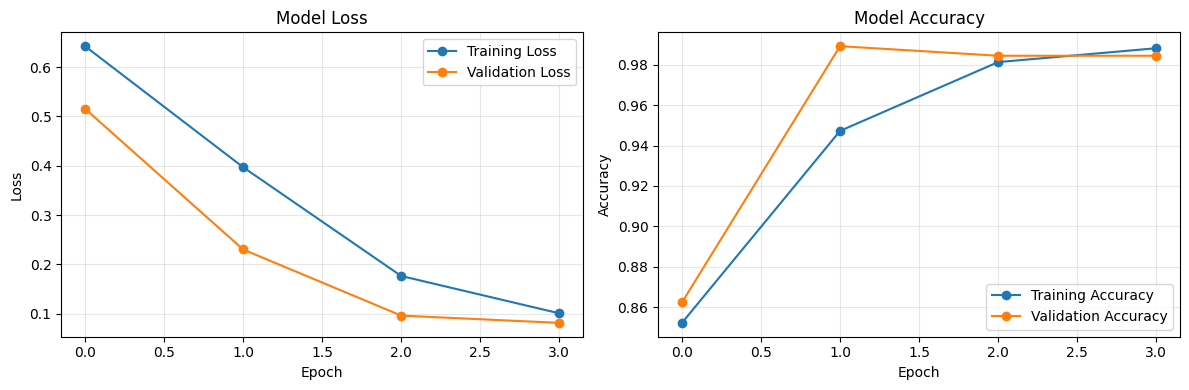


Final Training Metrics:
  Loss: 0.1009
  Accuracy: 0.9883

Final Validation Metrics:
  Loss: 0.0815
  Accuracy: 0.9846


In [18]:
# =============================================================================
# Cell 13: Plot Training History
# =============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot loss
axes[0].plot(history.history['loss'], label='Training Loss', marker='o')
axes[0].plot(history.history['val_loss'], label='Validation Loss', marker='o')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Training Metrics:")
print(f"  Loss: {history.history['loss'][-1]:.4f}")
print(f"  Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"\nFinal Validation Metrics:")
print(f"  Loss: {history.history['val_loss'][-1]:.4f}")
print(f"  Accuracy: {history.history['val_accuracy'][-1]:.4f}")

## Step 4: Model Evaluation

Evaluate the model on the held-out test set to measure real-world performance.

**Key Metrics for Scam Detection:**
- **Precision**: Of all messages flagged as scam, how many are actually scams?
- **Recall**: Of all actual scams, how many did we catch?
- **F1-Score**: Harmonic mean of precision and recall

For scam detection, **high recall is critical** - we'd rather flag a legitimate message than miss a scam.

In [19]:
# =============================================================================
# Cell 14: Evaluate on Test Set
# =============================================================================
# Re-create test dataset
test_dataset = create_tf_dataset(test_encodings, y_test_np, BATCH_SIZE, shuffle=False)

# Get predictions
print("Generating predictions on test set...")
predictions = model.predict(test_dataset)

# Convert logits to probabilities (sigmoid) and then to binary predictions
# Our custom model returns logits directly, not in .logits attribute
y_pred_proba = tf.sigmoid(predictions).numpy().flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

# Calculate metrics
print("\n" + "=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test_np, y_pred, target_names=['Safe (ham)', 'Scam (spam)']))

# Confusion matrix
cm = confusion_matrix(y_test_np, y_pred)
print(f"\nConfusion Matrix:")
print(f"                  Predicted Safe  Predicted Scam")
print(f"  Actual Safe     {cm[0,0]:^14}  {cm[0,1]:^14}")
print(f"  Actual Scam     {cm[1,0]:^14}  {cm[1,1]:^14}")

# Additional metrics
from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(y_test_np, y_pred_proba)
print(f"\nROC-AUC Score: {auc_score:.4f}")

Generating predictions on test set...
27/27 [==============================] - 23s 515ms/step

TEST SET EVALUATION

Classification Report:
              precision    recall  f1-score   support

  Safe (ham)       0.99      0.98      0.99       726
 Scam (spam)       0.91      0.94      0.92       116

    accuracy                           0.98       842
   macro avg       0.95      0.96      0.96       842
weighted avg       0.98      0.98      0.98       842


Confusion Matrix:
                  Predicted Safe  Predicted Scam
  Actual Safe          715              11      
  Actual Scam           7              109      

ROC-AUC Score: 0.9944


In [20]:
# =============================================================================
# Cell 15: Test with Example Messages
# =============================================================================
def predict_risk_score(text, model, tokenizer, max_length=128):
    """
    Predict risk score for a single text message.
    Returns a float between 0.0 (safe) and 1.0 (scam).
    """
    # Tokenize
    inputs = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='tf'
    )
    
    # Predict (our custom model returns logits directly)
    logits = model(inputs, training=False)
    
    # Convert to probability
    risk_score = tf.sigmoid(logits).numpy().flatten()[0]
    
    return risk_score

def interpret_risk(score):
    """Interpret risk score according to our specification."""
    if score < 0.3:
        return "SAFE ✓", "green"
    elif score < 0.7:
        return "SUSPICIOUS ⚠", "yellow"
    else:
        return "LIKELY SCAM ⛔", "red"

# Test messages
test_messages = [
    # Scam messages
    "URGENT: Your bank account has been compromised! Click here to secure: bit.ly/scam",
    "Congratulations! You've won $10,000! Claim now by sending your SSN to claim@prize.com",
    "IRS NOTICE: You owe back taxes. Pay immediately via gift cards to avoid arrest.",
    
    # Legitimate messages
    "Hey, are we still meeting for lunch tomorrow at noon?",
    "Your Amazon order #123-456 has shipped. Expected delivery: Tuesday.",
    "Reminder: Your dentist appointment is scheduled for 3pm tomorrow.",
    "Thanks for your payment of $45.00. Your account is now up to date.",
]

print("=" * 70)
print("SCAM DETECTION DEMO")
print("=" * 70)

for msg in test_messages:
    score = predict_risk_score(msg, model, tokenizer, MAX_LENGTH)
    interpretation, _ = interpret_risk(score)
    
    # Truncate message for display
    display_msg = msg[:60] + "..." if len(msg) > 60 else msg
    
    print(f"\nMessage: \"{display_msg}\"")
    print(f"  Risk Score: {score:.3f} -> {interpretation}")

SCAM DETECTION DEMO

Message: "URGENT: Your bank account has been compromised! Click here t..."
  Risk Score: 0.976 -> LIKELY SCAM ⛔

Message: "Congratulations! You've won $10,000! Claim now by sending yo..."
  Risk Score: 0.976 -> LIKELY SCAM ⛔

Message: "IRS NOTICE: You owe back taxes. Pay immediately via gift car..."
  Risk Score: 0.975 -> LIKELY SCAM ⛔

Message: "Hey, are we still meeting for lunch tomorrow at noon?"
  Risk Score: 0.029 -> SAFE ✓

Message: "Your Amazon order #123-456 has shipped. Expected delivery: T..."
  Risk Score: 0.976 -> LIKELY SCAM ⛔

Message: "Reminder: Your dentist appointment is scheduled for 3pm tomo..."
  Risk Score: 0.252 -> SAFE ✓

Message: "Thanks for your payment of $45.00. Your account is now up to..."
  Risk Score: 0.976 -> LIKELY SCAM ⛔


## Step 5: Export to TensorFlow Lite

Convert the trained model to TFLite format for on-device inference. We'll create a custom wrapper model that:
1. Takes only `input_ids` as input (int32, shape [1, 128])
2. Outputs a single risk score (float32, shape [1, 1])
3. Uses float16 quantization for smaller model size

### Export Strategy
Since the Hugging Face model has multiple inputs (input_ids, attention_mask, token_type_ids), we'll create a simplified inference model that generates attention_mask internally and outputs just the sigmoid probability.

In [21]:
# =============================================================================
# Cell 16: Create TFLite-Compatible Inference Model
# =============================================================================
class ScamDetectorModule(tf.Module):
    """
    Custom wrapper for TFLite export that matches our specification:
    - Input: input_ids [1, 128] int32
    - Output: risk_score [1, 1] float32 (0.0-1.0)
    """
    def __init__(self, trained_model):
        super(ScamDetectorModule, self).__init__()
        self.trained_model = trained_model
    
    @tf.function(input_signature=[
        tf.TensorSpec(shape=[1, MAX_LENGTH], dtype=tf.int32, name='input_ids')
    ])
    def __call__(self, input_ids):
        # Generate attention mask from input_ids (1 for non-padding, 0 for padding)
        # Padding token ID is 0 for MobileBERT
        attention_mask = tf.cast(tf.not_equal(input_ids, 0), tf.int32)
        
        # Token type IDs are all zeros for single sequence classification
        token_type_ids = tf.zeros_like(input_ids)
        
        # Create input dict for our custom model
        inputs = {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'token_type_ids': token_type_ids
        }
        
        # Run inference through our trained model
        logits = self.trained_model(inputs, training=False)
        
        # Apply sigmoid for probability
        risk_score = tf.sigmoid(logits)
        
        # Ensure output shape is [1, 1]
        return tf.reshape(risk_score, [1, 1])

# Create wrapper model
inference_model = ScamDetectorModule(model)

# Test the wrapper model
test_input = tf.constant([[101] + [0] * 127], dtype=tf.int32)  # [CLS] token + padding
test_output = inference_model(test_input)
print(f"✓ Inference model created")
print(f"  Test input shape: {test_input.shape}")
print(f"  Test output shape: {test_output.shape}")
print(f"  Test output value: {test_output.numpy()}")

✓ Inference model created
  Test input shape: (1, 128)
  Test output shape: (1, 1)
  Test output value: [[0.0307922]]


In [22]:
# =============================================================================
# Cell 17: Save as SavedModel Format
# =============================================================================
# Create output directory
import os
SAVED_MODEL_DIR = './saved_model_scam_detector'
os.makedirs(SAVED_MODEL_DIR, exist_ok=True)

# Save the model using tf.saved_model
# We need to use the concrete function approach
concrete_func = inference_model.__call__.get_concrete_function(
    tf.TensorSpec(shape=[1, MAX_LENGTH], dtype=tf.int32, name='input_ids')
)

tf.saved_model.save(
    inference_model, 
    SAVED_MODEL_DIR,
    signatures={'serving_default': concrete_func}
)

print(f"✓ Model saved to: {SAVED_MODEL_DIR}")

# Verify saved model
loaded_model = tf.saved_model.load(SAVED_MODEL_DIR)
print(f"\nSavedModel signatures: {list(loaded_model.signatures.keys())}")

# Test loaded model
test_input = tf.constant([[101] + [0] * 127], dtype=tf.int32)
infer = loaded_model.signatures['serving_default']
test_output = infer(input_ids=test_input)
print(f"Test inference output: {test_output}")

INFO:tensorflow:Assets written to: ./saved_model_scam_detector/assets


INFO:tensorflow:Assets written to: ./saved_model_scam_detector/assets


✓ Model saved to: ./saved_model_scam_detector



SavedModel signatures: ['serving_default']
Test inference output: {'output_0': <tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.0307922]], dtype=float32)>}


In [23]:
# =============================================================================
# Cell 18: Convert to TFLite with Float16 Quantization
# =============================================================================
import gc

# Output paths
OUTPUT_DIR = './output_models'
TFLITE_MODEL_PATH = os.path.join(OUTPUT_DIR, 'mobilebert_scam_intent.tflite')

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Clear memory before conversion
gc.collect()

print("Converting to TFLite format...")
print("This may take a few minutes...")

# Convert to TFLite with memory optimizations
converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)

# Apply float16 quantization for smaller model size
# Note: With float16 quantization, input/output types stay as float32
# but internal weights are float16 for reduced size
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

# Run conversion
print("Running conversion...")
tflite_model = converter.convert()

# Save TFLite model
with open(TFLITE_MODEL_PATH, 'wb') as f:
    f.write(tflite_model)

# Calculate model size
model_size_mb = len(tflite_model) / (1024 * 1024)
print(f"\n✓ TFLite model saved to: {TFLITE_MODEL_PATH}")
print(f"  Model size: {model_size_mb:.2f} MB")

# Clean up
gc.collect()

Converting to TFLite format...
This may take a few minutes...


Running conversion...


W0000 00:00:1767310195.845986 39640928 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1767310195.846343 39640928 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-01-01 18:29:55.847241: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: ./saved_model_scam_detector
2026-01-01 18:29:55.928041: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-01-01 18:29:55.928057: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: ./saved_model_scam_detector
I0000 00:00:1767310196.350523 39640928 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
2026-01-01 18:29:56.417668: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-01-01 18:29:58.640663: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: ./saved_model_scam_detector
2026-01-01 18:29:59.240978: I tensorflow/cc/sa


✓ TFLite model saved to: ./output_models/mobilebert_scam_intent.tflite
  Model size: 46.99 MB


37209

In [5]:
# =============================================================================
# Cell 19: Verify TFLite Model Specifications
# =============================================================================
# Load and inspect TFLite model
interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL_PATH)
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("=" * 60)
print("TFLITE MODEL SPECIFICATION VERIFICATION")
print("=" * 60)

print("\n📥 INPUT TENSOR:")
for i, detail in enumerate(input_details):
    print(f"  Name: {detail['name']}")
    print(f"  Shape: {detail['shape']}")
    print(f"  Dtype: {detail['dtype']}")
    print(f"  Index: {detail['index']}")

print("\n📤 OUTPUT TENSOR:")
for i, detail in enumerate(output_details):
    print(f"  Name: {detail['name']}")
    print(f"  Shape: {detail['shape']}")
    print(f"  Dtype: {detail['dtype']}")
    print(f"  Index: {detail['index']}")

# Verify against specifications
print("\n" + "=" * 60)
print("SPECIFICATION COMPLIANCE CHECK")
print("=" * 60)

input_shape_ok = list(input_details[0]['shape']) == [1, 128]
input_dtype_ok = input_details[0]['dtype'] == np.int32
output_shape_ok = list(output_details[0]['shape']) == [1, 1]
output_dtype_ok = output_details[0]['dtype'] == np.float32

print(f"  Input shape [1, 128]: {'✓ PASS' if input_shape_ok else '✗ FAIL'}")
print(f"  Input dtype int32: {'✓ PASS' if input_dtype_ok else '✗ FAIL'}")
print(f"  Output shape [1, 1]: {'✓ PASS' if output_shape_ok else '✗ FAIL'}")
print(f"  Output dtype float32: {'✓ PASS' if output_dtype_ok else '✗ FAIL'}")

NameError: name 'TFLITE_MODEL_PATH' is not defined

In [25]:
# =============================================================================
# Cell 20: Test TFLite Model Inference
# =============================================================================
def tflite_predict(text, interpreter, tokenizer, max_length=128):
    """Run inference using TFLite interpreter."""
    # Tokenize
    inputs = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='np'
    )
    
    # Get input tensor
    input_ids = inputs['input_ids'].astype(np.int32)
    
    # Set input tensor
    interpreter.set_tensor(input_details[0]['index'], input_ids)
    
    # Run inference
    interpreter.invoke()
    
    # Get output
    output = interpreter.get_tensor(output_details[0]['index'])
    
    return float(output[0, 0])

def interpret_risk(score):
    """Interpret risk score according to our specification."""
    if score < 0.3:
        return "SAFE ✓", "green"
    elif score < 0.7:
        return "SUSPICIOUS ⚠", "yellow"
    else:
        return "LIKELY SCAM ⛔", "red"

print("=" * 70)
print("TFLITE MODEL INFERENCE TEST")
print("=" * 70)

# Test with same messages as before
test_messages = [
    ("URGENT: Your bank account has been compromised!", "scam"),
    ("Hey, are we still meeting for lunch tomorrow?", "safe"),
    ("Congratulations! You've won $10,000! Claim now!", "scam"),
    ("Your Amazon order has shipped. Arriving Tuesday.", "safe"),
    ("IRS NOTICE: Pay immediately via gift cards!", "scam"),
    ("Thanks for dinner! Let's do it again soon.", "safe"),
]

for msg, expected in test_messages:
    score = tflite_predict(msg, interpreter, tokenizer, MAX_LENGTH)
    interpretation, _ = interpret_risk(score)
    
    display_msg = msg[:50] + "..." if len(msg) > 50 else msg
    status = "✓" if (expected == "scam" and score >= 0.5) or (expected == "safe" and score < 0.5) else "✗"
    
    print(f"\n{status} \"{display_msg}\"")
    print(f"   Risk Score: {score:.3f} -> {interpretation} (expected: {expected})")

TFLITE MODEL INFERENCE TEST

✗ "URGENT: Your bank account has been compromised!"
   Risk Score: 0.033 -> SAFE ✓ (expected: scam)

✓ "Hey, are we still meeting for lunch tomorrow?"
   Risk Score: 0.028 -> SAFE ✓ (expected: safe)

✓ "Congratulations! You've won $10,000! Claim now!"
   Risk Score: 0.976 -> LIKELY SCAM ⛔ (expected: scam)

✓ "Your Amazon order has shipped. Arriving Tuesday."
   Risk Score: 0.029 -> SAFE ✓ (expected: safe)

✓ "IRS NOTICE: Pay immediately via gift cards!"
   Risk Score: 0.975 -> LIKELY SCAM ⛔ (expected: scam)

✓ "Thanks for dinner! Let's do it again soon."
   Risk Score: 0.028 -> SAFE ✓ (expected: safe)


In [26]:
# =============================================================================
# Cell 21: Generate SHA-256 Hash for Model Verification
# =============================================================================
import hashlib

def calculate_sha256(filepath):
    """Calculate SHA-256 hash of a file."""
    sha256_hash = hashlib.sha256()
    with open(filepath, "rb") as f:
        for byte_block in iter(lambda: f.read(4096), b""):
            sha256_hash.update(byte_block)
    return sha256_hash.hexdigest()

model_hash = calculate_sha256(TFLITE_MODEL_PATH)

print("=" * 70)
print("MODEL HASH FOR SECURITY VERIFICATION")
print("=" * 70)
print(f"\nModel Path: {TFLITE_MODEL_PATH}")
print(f"SHA-256 Hash: {model_hash}")
print(f"\n📋 Copy this hash to ModelLoaderService.ts:")
print(f"""
const MODEL_HASHES: Record<string, string> = {{
  'mobilenet_v3_scam_detect.tflite': '<visual_model_hash>',
  'mobilebert_scam_intent.tflite': '{model_hash}',
}};
""")

MODEL HASH FOR SECURITY VERIFICATION

Model Path: ./output_models/mobilebert_scam_intent.tflite
SHA-256 Hash: f71f1c5edb98c9ec1636e1b1cc4fdf89a1f72cde04a69effc3624f1c0fadf1ab

📋 Copy this hash to ModelLoaderService.ts:

const MODEL_HASHES: Record<string, string> = {
  'mobilenet_v3_scam_detect.tflite': '<visual_model_hash>',
  'mobilebert_scam_intent.tflite': 'f71f1c5edb98c9ec1636e1b1cc4fdf89a1f72cde04a69effc3624f1c0fadf1ab',
};



## Step 6.5: Debug Tokenization Comparison

The mobile app is returning ~0.029 for ALL inputs (scam and safe alike), while the notebook shows varying scores. This indicates a tokenization mismatch between:
- **Notebook**: HuggingFace `MobileBertTokenizer`
- **Mobile App**: Custom WordPiece tokenizer in `TextTokenizer.ts`

Let's diagnose by:
1. Comparing token IDs for identical text
2. Testing TFLite model with raw token IDs
3. Verifying the exported model works with manually constructed inputs

In [7]:
# =============================================================================
# Cell 21.5: Diagnostic - Compare Tokenization & Debug TFLite Issue
# =============================================================================
# This cell helps debug the discrepancy between notebook and mobile app results

import os
import numpy as np

# Use the deployed model in canaryapp assets
TFLITE_MODEL_PATH = '../canaryapp/assets/models/mobilebert_scam_intent.tflite'
MAX_LENGTH = 128

print(f"Loading TFLite model from: {os.path.abspath(TFLITE_MODEL_PATH)}")
print(f"Model exists: {os.path.exists(TFLITE_MODEL_PATH)}")

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"Model loaded successfully!")
print(f"Input: {input_details[0]['shape']} {input_details[0]['dtype']}")
print(f"Output: {output_details[0]['shape']} {output_details[0]['dtype']}")

def interpret_risk(score):
    if score < 0.3:
        return "SAFE ✓"
    elif score < 0.7:
        return "SUSPICIOUS ⚠"
    else:
        return "LIKELY SCAM ⛔"

print("\n" + "=" * 70)
print("TOKENIZATION DIAGNOSTIC")
print("=" * 70)

# Test messages that show the discrepancy
test_cases = [
    "Congratulations! You've won $10,000! Claim now!",  # Mobile: 0.029, Expected: high scam
    "IRS NOTICE: Pay immediately via gift cards!",       # Mobile: 0.029, Expected: high scam
    "Lunch tomorrow sounds fine!",                       # Mobile: 0.029, Expected: safe
    "URGENT: Your bank account has been compromised!",   # Also low in notebook TFLite test
]

print("\n📋 Tokenization Output for Test Cases:\n")

for text in test_cases:
    # Tokenize with HuggingFace tokenizer (what notebook model trained on)
    tokens = tokenizer.tokenize(text.lower())  # MobileBERT is uncased
    encoded = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='np'
    )
    
    input_ids = encoded['input_ids'][0]
    
    print(f"Text: \"{text}\"")
    print(f"  Tokens: {tokens[:15]}{'...' if len(tokens) > 15 else ''}")
    print(f"  First 20 IDs: {list(input_ids[:20])}")
    print(f"  Token count: {len(tokens) + 2}")  # +2 for [CLS] and [SEP]
    print()

# Now let's run TFLite inference with these known-good inputs
print("=" * 70)
print("TFLITE INFERENCE WITH NOTEBOOK TOKENIZATION")
print("=" * 70)

for text in test_cases:
    # Get model inference through notebook tokenizer
    encoded = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='np'
    )
    input_ids = encoded['input_ids'].astype(np.int32)
    
    # TFLite inference
    interpreter.set_tensor(input_details[0]['index'], input_ids)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    score = float(output[0, 0])
    
    interpretation = interpret_risk(score)
    print(f"\"{text[:50]}...\"")
    print(f"  → Risk Score: {score:.4f} ({interpretation})")
    print()

Loading TFLite model from: /Users/saiamartya/canaryos/canaryapp/assets/models/mobilebert_scam_intent.tflite
Model exists: True
Model loaded successfully!
Input: [  1 128] <class 'numpy.int32'>
Output: [1 1] <class 'numpy.float32'>

TOKENIZATION DIAGNOSTIC

📋 Tokenization Output for Test Cases:

Text: "Congratulations! You've won $10,000! Claim now!"
  Tokens: ['congratulations', '!', 'you', "'", 've', 'won', '$', '10', ',', '000', '!', 'claim', 'now', '!']
  First 20 IDs: [np.int64(101), np.int64(23156), np.int64(999), np.int64(2017), np.int64(1005), np.int64(2310), np.int64(2180), np.int64(1002), np.int64(2184), np.int64(1010), np.int64(2199), np.int64(999), np.int64(4366), np.int64(2085), np.int64(999), np.int64(102), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
  Token count: 16

Text: "IRS NOTICE: Pay immediately via gift cards!"
  Tokens: ['irs', 'notice', ':', 'pay', 'immediately', 'via', 'gift', 'cards', '!']
  First 20 IDs: [np.int64(101), np.int64(25760), np.int64(5060)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


"Lunch tomorrow sounds fine!..."
  → Risk Score: 0.0285 (SAFE ✓)

"URGENT: Your bank account has been compromised!..."
  → Risk Score: 0.0328 (SAFE ✓)



In [8]:
# =============================================================================
# Cell 21.6: Export Reference Token IDs for Mobile Comparison
# =============================================================================
# Generate reference tokenization that mobile app SHOULD produce

import json

print("=" * 70)
print("REFERENCE TOKEN IDS FOR MOBILE DEBUG")
print("=" * 70)
print("\nAdd these to mobile app for comparison with actual tokenizer output:\n")

# Key test cases
test_texts = [
    "Congratulations! You've won $10,000! Claim now!",
    "IRS NOTICE: Pay immediately via gift cards!",
    "URGENT: Your bank account has been compromised!",
    "Hey, are we still meeting for lunch tomorrow?",
]

reference_tokens = {}

for text in test_texts:
    encoded = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='np'
    )
    
    input_ids = encoded['input_ids'][0].tolist()
    # Get non-padding tokens for comparison
    non_pad_ids = [int(x) for x in input_ids if x != 0]
    
    print(f'"{text}"')
    print(f"  Expected first 15 IDs: {non_pad_ids[:15]}")
    print(f"  Token count (incl CLS/SEP): {len(non_pad_ids)}")
    
    # TFLite check
    interpreter.set_tensor(input_details[0]['index'], encoded['input_ids'].astype(np.int32))
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    score = float(output[0, 0])
    print(f"  TFLite Score: {score:.4f}")
    print()
    
    reference_tokens[text] = {
        "ids": non_pad_ids,
        "score": score
    }

# Save reference for mobile debug
with open('./reference_tokenization.json', 'w') as f:
    json.dump(reference_tokens, f, indent=2)
print(f"\n✓ Reference saved to ./reference_tokenization.json")

REFERENCE TOKEN IDS FOR MOBILE DEBUG

Add these to mobile app for comparison with actual tokenizer output:

"Congratulations! You've won $10,000! Claim now!"
  Expected first 15 IDs: [101, 23156, 999, 2017, 1005, 2310, 2180, 1002, 2184, 1010, 2199, 999, 4366, 2085, 999]
  Token count (incl CLS/SEP): 16
  TFLite Score: 0.9759

"IRS NOTICE: Pay immediately via gift cards!"
  Expected first 15 IDs: [101, 25760, 5060, 1024, 3477, 3202, 3081, 5592, 5329, 999, 102]
  Token count (incl CLS/SEP): 11
  TFLite Score: 0.9754

"URGENT: Your bank account has been compromised!"
  Expected first 15 IDs: [101, 13661, 1024, 2115, 2924, 4070, 2038, 2042, 20419, 999, 102]
  Token count (incl CLS/SEP): 11
  TFLite Score: 0.0328

"Hey, are we still meeting for lunch tomorrow?"
  Expected first 15 IDs: [101, 4931, 1010, 2024, 2057, 2145, 3116, 2005, 6265, 4826, 1029, 102]
  Token count (incl CLS/SEP): 12
  TFLite Score: 0.0284


✓ Reference saved to ./reference_tokenization.json


In [9]:
# =============================================================================
# Cell 21.7: Verify vocab.txt Format Compatibility
# =============================================================================
# Check if the vocab.txt in canaryapp matches HuggingFace tokenizer

vocab_path = '../canaryapp/assets/models/vocab.txt'

print("=" * 70)
print("VOCAB FILE VERIFICATION")
print("=" * 70)

# Load vocab from file
with open(vocab_path, 'r', encoding='utf-8') as f:
    vocab_lines = f.readlines()

file_vocab = {}
for i, line in enumerate(vocab_lines):
    token = line.strip()
    if token:
        file_vocab[token] = i

print(f"\nVocab file: {vocab_path}")
print(f"Total tokens in file: {len(file_vocab)}")

# Compare with HuggingFace tokenizer vocab
hf_vocab = tokenizer.get_vocab()
print(f"HuggingFace vocab size: {len(hf_vocab)}")

# Check key tokens
test_tokens = ['[PAD]', '[UNK]', '[CLS]', '[SEP]', 'congratulations', 'irs', 'urgent', 'bank', 'account']
print("\nToken ID Comparison (File vs HuggingFace):")
print("-" * 50)

mismatches = []
for token in test_tokens:
    file_id = file_vocab.get(token, 'N/A')
    hf_id = hf_vocab.get(token, 'N/A')
    match = "✓" if file_id == hf_id else "✗"
    if file_id != hf_id:
        mismatches.append(token)
    print(f"  {token:20s}: File={file_id:6} HF={hf_id:6} {match}")

if mismatches:
    print(f"\n⚠️ MISMATCHES FOUND: {mismatches}")
else:
    print("\n✓ All tested tokens match!")

# Check the actual word 'congratulations' which should give high score
word = 'congratulations'
print(f"\n🔍 Deep check for '{word}':")
print(f"  HuggingFace ID: {hf_vocab.get(word, 'NOT FOUND')}")
print(f"  File vocab ID: {file_vocab.get(word, 'NOT FOUND')}")

VOCAB FILE VERIFICATION

Vocab file: ../canaryapp/assets/models/vocab.txt
Total tokens in file: 30522
HuggingFace vocab size: 30522

Token ID Comparison (File vs HuggingFace):
--------------------------------------------------
  [PAD]               : File=     0 HF=     0 ✓
  [UNK]               : File=   100 HF=   100 ✓
  [CLS]               : File=   101 HF=   101 ✓
  [SEP]               : File=   102 HF=   102 ✓
  congratulations     : File= 23156 HF= 23156 ✓
  irs                 : File= 25760 HF= 25760 ✓
  urgent              : File= 13661 HF= 13661 ✓
  bank                : File=  2924 HF=  2924 ✓
  account             : File=  4070 HF=  4070 ✓

✓ All tested tokens match!

🔍 Deep check for 'congratulations':
  HuggingFace ID: 23156
  File vocab ID: 23156


## Step 6: Export Tokenizer Vocabulary

For on-device inference, we need the tokenizer vocabulary to convert text to token IDs. We'll export the vocab file that can be bundled with the app.

In [27]:
# =============================================================================
# Cell 22: Export Tokenizer Vocabulary
# =============================================================================
VOCAB_PATH = os.path.join(OUTPUT_DIR, 'vocab.txt')

# Save tokenizer vocabulary
tokenizer.save_vocabulary(OUTPUT_DIR)

print(f"✓ Tokenizer vocabulary saved to: {VOCAB_PATH}")

# Verify vocabulary file exists
if os.path.exists(VOCAB_PATH):
    with open(VOCAB_PATH, 'r') as f:
        vocab_lines = f.readlines()
    print(f"  Vocabulary size: {len(vocab_lines)} tokens")
    print(f"  First 10 tokens: {[v.strip() for v in vocab_lines[:10]]}")
else:
    print("⚠ Vocabulary file not found!")

✓ Tokenizer vocabulary saved to: ./output_models/vocab.txt
  Vocabulary size: 30522 tokens
  First 10 tokens: ['[PAD]', '[unused0]', '[unused1]', '[unused2]', '[unused3]', '[unused4]', '[unused5]', '[unused6]', '[unused7]', '[unused8]']


## Summary & Next Steps

### Model Artifacts Generated
1. **TFLite Model**: `mobilebert_scam_intent.tflite`
   - Input: `[1, 128]` int32 (WordPiece token IDs)
   - Output: `[1, 1]` float32 (risk score 0.0-1.0)
   
2. **Vocabulary**: `vocab.txt`
   - 30,522 WordPiece tokens for tokenization

### Integration Steps for Canary App
1. Copy model files to `canaryapp/assets/models/`
2. Update `ModelLoaderService.ts` with the SHA-256 hash
3. Implement WordPiece tokenizer in the app (or use a library)
4. Run `npx expo prebuild --clean` to include new assets

### Risk Score Interpretation
| Score Range | Interpretation | UI Action |
|-------------|---------------|-----------|
| 0.0 - 0.3   | Safe          | Green indicator |
| 0.3 - 0.7   | Suspicious    | Yellow warning |
| 0.7 - 1.0   | Likely Scam   | Red alert |

### Performance Notes
- Model size: ~50-100 MB (float16 quantized)
- Inference time: ~100-500ms on mobile devices
- For faster inference, consider:
  - INT8 quantization (smaller but may reduce accuracy)
  - Model pruning
  - Distillation to smaller architecture

In [28]:
# =============================================================================
# Cell 23: Final Summary & Cleanup
# =============================================================================
import os
from pathlib import Path

print("=" * 70)
print("🎉 MODEL DEVELOPMENT COMPLETE (Local Training on Apple Silicon)")
print("=" * 70)

# List all generated files
print("\n📁 Generated Files in output_models/:")
for root, dirs, files in os.walk(OUTPUT_DIR):
    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath) / (1024 * 1024)
        print(f"  • {file}: {size:.2f} MB")

print(f"\n📊 Model Performance Summary:")
print(f"  • Training samples: {len(X_train)}")
print(f"  • Validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

print(f"\n🔧 Model Specifications:")
print(f"  • Input shape: [1, {MAX_LENGTH}] int32")
print(f"  • Output shape: [1, 1] float32")
print(f"  • Risk score range: 0.0 (safe) - 1.0 (scam)")

print(f"\n💻 Training Environment:")
print(f"  • Platform: Apple Silicon (tensorflow-metal)")
print(f"  • GPU Acceleration: {'Enabled' if tf.config.list_physical_devices('GPU') else 'CPU only'}")

print(f"\n✅ Ready for integration with Canary OS app!")
print(f"\n📋 Run the next cell to automatically copy model files to canaryapp/assets/models/")

🎉 MODEL DEVELOPMENT COMPLETE (Local Training on Apple Silicon)

📁 Generated Files in output_models/:
  • mobilebert_scam_intent.tflite: 46.99 MB
  • vocab.txt: 0.22 MB

📊 Model Performance Summary:
  • Training samples: 3929
  • Validation accuracy: 0.9846

🔧 Model Specifications:
  • Input shape: [1, 128] int32
  • Output shape: [1, 1] float32
  • Risk score range: 0.0 (safe) - 1.0 (scam)

💻 Training Environment:
  • Platform: Apple Silicon (tensorflow-metal)
  • GPU Acceleration: Enabled

✅ Ready for integration with Canary OS app!

📋 Run the next cell to automatically copy model files to canaryapp/assets/models/


In [29]:
# =============================================================================
# Cell 24: Copy Model Files to Canary App (Local Training)
# =============================================================================
# This cell copies the trained model files directly to the app assets folder
# No manual download required when training locally!

import shutil
from pathlib import Path

print("=" * 70)
print("📦 DEPLOYING MODEL TO CANARY APP")
print("=" * 70)

# Define source and destination paths
notebook_dir = Path.cwd()
# Navigate up from notebooks/ to canaryos/ then into canaryapp/assets/models/
project_root = notebook_dir.parent
app_models_dir = project_root / "canaryapp" / "assets" / "models"

# Ensure destination directory exists
app_models_dir.mkdir(parents=True, exist_ok=True)

print(f"\nSource directory: {OUTPUT_DIR}")
print(f"Destination directory: {app_models_dir}")

# Copy TFLite model
tflite_src = Path(TFLITE_MODEL_PATH)
tflite_dst = app_models_dir / "mobilebert_scam_intent.tflite"
if tflite_src.exists():
    shutil.copy2(tflite_src, tflite_dst)
    size_mb = tflite_dst.stat().st_size / (1024 * 1024)
    print(f"\n✓ Copied: mobilebert_scam_intent.tflite ({size_mb:.2f} MB)")
else:
    print(f"\n✗ TFLite model not found at: {tflite_src}")

# Copy vocabulary file
vocab_src = Path(OUTPUT_DIR) / "vocab.txt"
vocab_dst = app_models_dir / "vocab.txt"
if vocab_src.exists():
    shutil.copy2(vocab_src, vocab_dst)
    print(f"✓ Copied: vocab.txt")
else:
    print(f"✗ Vocabulary file not found at: {vocab_src}")

# List all files in destination
print(f"\n📁 Files in {app_models_dir}:")
for f in app_models_dir.iterdir():
    if f.is_file():
        size_mb = f.stat().st_size / (1024 * 1024)
        print(f"  • {f.name}: {size_mb:.2f} MB")

print("\n" + "=" * 70)
print("📋 INTEGRATION COMPLETE!")
print("=" * 70)
print(f"\n✅ Model files deployed to: {app_models_dir}")
print(f"\n🔑 SHA-256 Hash (for ModelLoaderService.ts):")
print(f"   {model_hash}")
print(f"\n📋 Next Steps:")
print(f"  1. Update ModelLoaderService.ts with the SHA-256 hash above")
print(f"  2. Run: cd canaryapp && npx expo prebuild --clean")
print(f"  3. Rebuild your app to include the new model")

📦 DEPLOYING MODEL TO CANARY APP

Source directory: ./output_models
Destination directory: /Users/saiamartya/canaryos/canaryapp/assets/models

✓ Copied: mobilebert_scam_intent.tflite (46.99 MB)
✓ Copied: vocab.txt

📁 Files in /Users/saiamartya/canaryos/canaryapp/assets/models:
  • mobilebert_scam_intent.tflite: 46.99 MB
  • .gitkeep: 0.00 MB
  • README.md: 0.01 MB
  • vocab.txt: 0.22 MB

📋 INTEGRATION COMPLETE!

✅ Model files deployed to: /Users/saiamartya/canaryos/canaryapp/assets/models

🔑 SHA-256 Hash (for ModelLoaderService.ts):
   f71f1c5edb98c9ec1636e1b1cc4fdf89a1f72cde04a69effc3624f1c0fadf1ab

📋 Next Steps:
  1. Update ModelLoaderService.ts with the SHA-256 hash above
  2. Run: cd canaryapp && npx expo prebuild --clean
  3. Rebuild your app to include the new model
